# Automated Lithology Classification from Subsurface Well Logs
**Course Project**: SCOA032 - Subsurface Characterization & Analytics  
**Dataset**: FORCE 2020 Benchmark Well Log Dataset (Well 15/9-23)  
**Objective**: Build an end-to-end Machine Learning pipeline to classify rock facies directly from down-hole sensor logs.


## 1. Project Setup & Package Imports
Import core scientific and machine learning libraries: Pandas, NumPy, Scikit-Learn, Matplotlib, and Seaborn.


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Libraries imported successfully.')


Libraries imported successfully.


## 2. Data Ingestion & Exploratory Data Analysis (EDA)
Load raw geophysical well log data from 15_9-23.csv and inspect raw columns, dimensions, and missingness.


In [2]:
raw_df = pd.read_csv('15_9-23.csv')
print(f'Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
raw_df.head(3)


Raw Dataset Shape: 11063 rows, 29 columns


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0


In [3]:
# Check missing value percentage across all sensor curves
missing_series = raw_df.isnull().sum()
missing_pct = (missing_series / len(raw_df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_series, 'Missing_Pct': missing_pct.round(2)})
missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)


,Missing_Count,Missing_Pct
RSHA,11063,100.00
SGR,11063,100.00
SP,11063,100.00
RMIC,11063,100.00
RXO,11063,100.00
MUDWEIGHT,11063,100.00
DTS,639,5.78
PEF,226,2.04
DTC,122,1.10
RMED,54,0.49


## 3. Data Cleaning & Lithology Mapping
1. **Drop 100% empty columns**: Curves such as RSHA, SGR, SP, MUDWEIGHT, RMIC, RXO contain zero recordings and are removed.
2. **Deduplication**: Verify row and depth uniqueness.
3. **Map Lithology Codes**: Apply the project's 7-class facies mapping.
4. **Clean Core Feature Records**: Retain rows with valid physical measurements across core sensors (GR, RHOB, NPHI, DTC, CALI, RDEP).


In [4]:
# 1. Lithology Facies Mapping
LITHOLOGY_MAPPING = {
    30000: 'Sandstone',
    65000: 'Shale',
    65030: 'Shale',   # Interbedded shale/sandstone grouped into Shale
    70000: 'Limestone',
    70032: 'Chalk',
    80000: 'Marl',
    90000: 'Tuff',
    99000: 'Coal'
}

# 2. Drop 100% empty columns
empty_cols = [c for c in raw_df.columns if raw_df[c].isnull().all()]
df_cleaned = raw_df.drop(columns=empty_cols).copy()

# 3. Deduplication
df_cleaned = df_cleaned.drop_duplicates().drop_duplicates(subset=['DEPTH_MD'])

# 4. Map target
df_cleaned['LITHOLOGY'] = df_cleaned['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(LITHOLOGY_MAPPING)

# 5. Core features filter
CORE_FEATURES = ['GR', 'RHOB', 'NPHI', 'DTC', 'CALI', 'RDEP']
df_cleaned = df_cleaned.dropna(subset=CORE_FEATURES).sort_values(by='DEPTH_MD').reset_index(drop=True)

# 6. Integer target encoding
class_names = sorted(df_cleaned['LITHOLOGY'].unique())
label_to_id = {name: idx for idx, name in enumerate(class_names)}
df_cleaned['LITHOLOGY_CODE'] = df_cleaned['LITHOLOGY'].map(label_to_id)

print(f'Cleaned Dataset Retention: {len(df_cleaned)} / {len(raw_df)} ({len(df_cleaned)/len(raw_df)*100:.2f}%)')
print('Target Facies Distribution:')
print(df_cleaned['LITHOLOGY'].value_counts())


Cleaned Dataset Retention: 10887 / 11063 (98.41%)
Target Facies Distribution:
LITHOLOGY
Shale        7625
Limestone    1630
Marl          912
Sandstone     553
Coal           74
Tuff           64
Chalk          29
Name: count, dtype: int64


## 4. Train-Test Splitting (Stratified 80/20 Strategy)
To ensure that rare geological facies (Chalk, Coal, Tuff) are proportionately represented in both sets, we apply an 80/20 Stratified Split (stratify=y).


In [5]:
train_df, test_df = train_test_split(
    df_cleaned,
    test_size=0.20,
    random_state=42,
    stratify=df_cleaned['LITHOLOGY_CODE']
)

print(f'Train samples: {len(train_df)} (80.0%) | Test samples: {len(test_df)} (20.0%)')


Train samples: 8709 (80.0%) | Test samples: 2178 (20.0%)


## 5. Feature Scaling / Normalization (StandardScaler)
Sensor logs operate on disparate physical dimensions (e.g., GR ranges 0-250 API, RHOB ranges 1.5-3.0 g/cmÂ³, DTC ranges 40-200 Âµs/ft).
StandardScaler is **fitted strictly on the training set ({train}$)** to guarantee zero data leakage.


In [6]:
scaler = StandardScaler()
scaler.fit(train_df[CORE_FEATURES])

SCALED_COLS = [f'{col}_scaled' for col in CORE_FEATURES]

train_scaled_arr = scaler.transform(train_df[CORE_FEATURES])
test_scaled_arr = scaler.transform(test_df[CORE_FEATURES])

for idx, col in enumerate(SCALED_COLS):
    train_df[col] = train_scaled_arr[:, idx]
    test_df[col] = test_scaled_arr[:, idx]

print('Feature Standardization Parameters (Training Set):')
for f, m, s in zip(CORE_FEATURES, scaler.mean_, scaler.scale_):
    print(f'  {f:6s}: Mean = {m:8.4f}, Std = {s:8.4f}')


Feature Standardization Parameters (Training Set):
  GR    : Mean =  85.6183, Std =  47.2958
  RHOB  : Mean =   2.3430, Std =   0.1661
  NPHI  : Mean =   0.3033, Std =   0.1285
  DTC   : Mean = 118.9331, Std =  29.4472
  CALI  : Mean =  12.0702, Std =   1.2517
  RDEP  : Mean =   1.4228, Std =   1.4472


## 6. Supervised Model Training (Random Forest Classifier)
We train a Random Forest Classifier (150 decision trees) to capture complex non-linear petrophysical boundaries, validated via 5-Fold Stratified Cross-Validation.


In [7]:
X_train = train_df[SCALED_COLS]
y_train = train_df['LITHOLOGY_CODE']
X_test = test_df[SCALED_COLS]
y_test = test_df['LITHOLOGY_CODE']

rf_model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'5-Fold CV Macro-F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

# Fit on training set
rf_model.fit(X_train, y_train)
print('Model training complete.')


5-Fold CV Macro-F1: 0.8614 (+/- 0.0553)


Model training complete.


## 7. Model Evaluation & Petrophysical Validation
Assess the trained model on the unseen test set using Accuracy, Macro-F1 score, Classification Report, and Confusion Matrix.


In [8]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Test Accuracy    : {acc*100:.2f}%')
print(f'Test Macro-F1    : {macro_f1:.4f}')
print(f'Test Weighted-F1 : {weighted_f1:.4f}')
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy    : 96.46%
Test Macro-F1    : 0.8684
Test Weighted-F1 : 0.9641

Detailed Classification Report:
              precision    recall  f1-score   support

       Chalk       1.00      0.67      0.80         6
        Coal       0.82      0.60      0.69        15
   Limestone       0.94      0.93      0.94       326
        Marl       0.89      0.90      0.89       182
   Sandstone       0.92      0.88      0.90       111
       Shale       0.98      0.99      0.99      1525
        Tuff       1.00      0.77      0.87        13

    accuracy                           0.96      2178
   macro avg       0.94      0.82      0.87      2178
weighted avg       0.96      0.96      0.96      2178



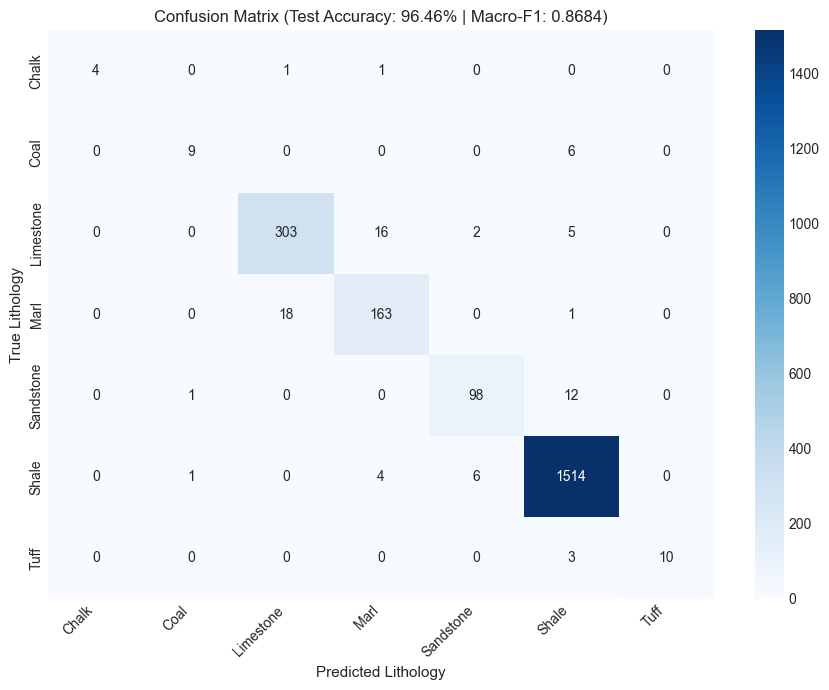

In [9]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Test Accuracy: {acc*100:.2f}% | Macro-F1: {macro_f1:.4f})', fontsize=12)
plt.xlabel('Predicted Lithology', fontsize=11)
plt.ylabel('True Lithology', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


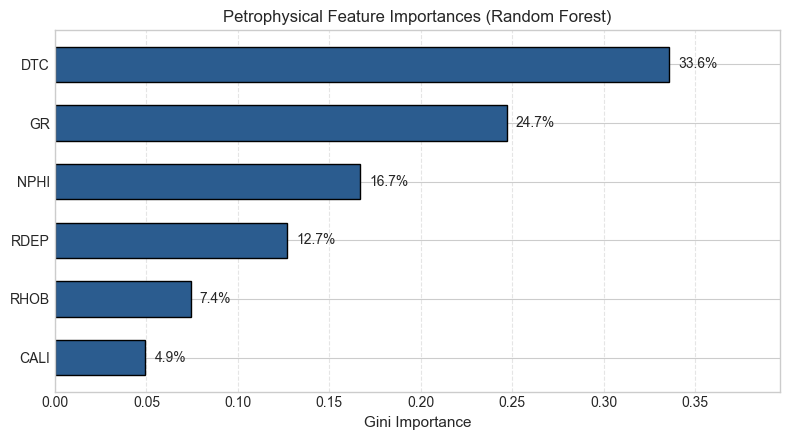

In [10]:
# Petrophysical Feature Importances
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=CORE_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(feat_imp.index, feat_imp.values, color='#2b5c8f', edgecolor='black', height=0.6)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.005, bar.get_y() + bar.get_height()/2, f'{w*100:.1f}%', va='center', fontsize=10)

plt.title('Petrophysical Feature Importances (Random Forest)', fontsize=12)
plt.xlabel('Gini Importance', fontsize=11)
plt.xlim(0, max(feat_imp.values) * 1.18)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Down-Hole Composite Well Log Visualization
Visualize down-hole sensor tracks alongside True Lithology vs. Predicted Lithology across depth.


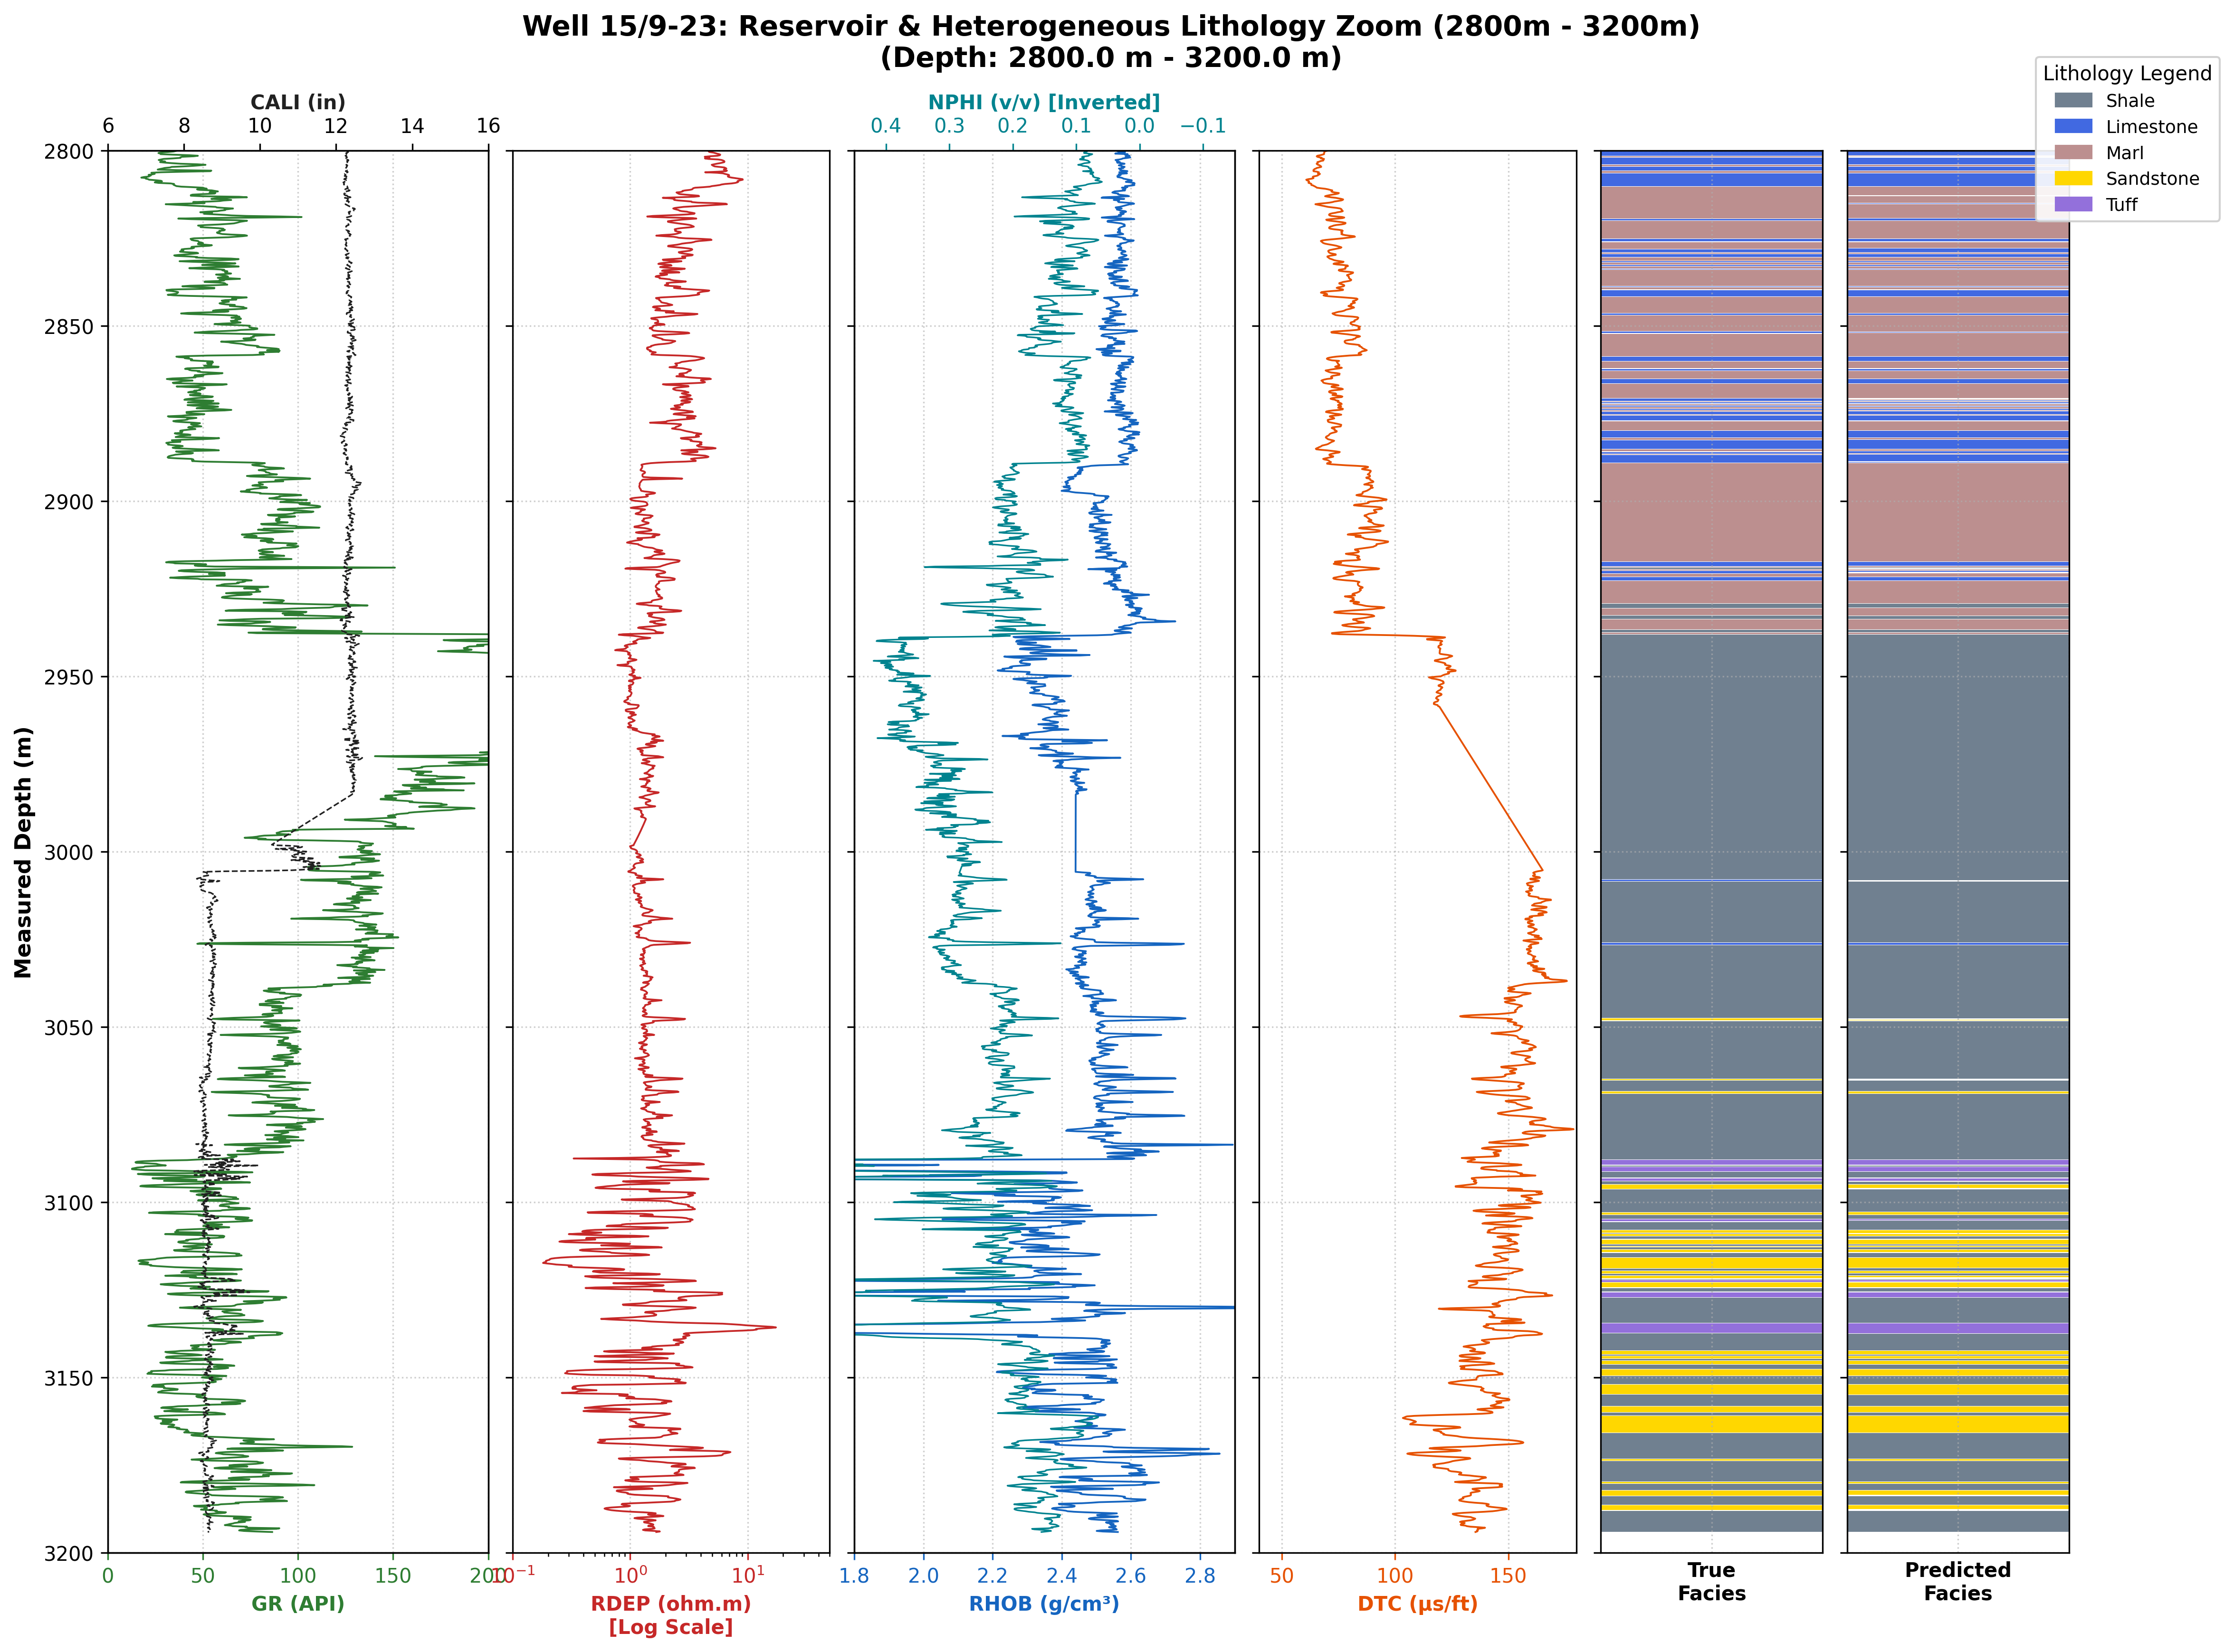

In [11]:
# Display generated composite well log visualization
from IPython.display import Image, display
display(Image(filename='well_log_reservoir_section.png'))
